# Video Game Sales Analysis
## Notebook 4: Advanced EDA & Feature Analysis

### Purpose

This notebook extends the previous exploratory and business analyses by examining deeper relationships among video game characteristics and sales performance. The goal is to identify important relationships, potential predictors, outliers, and patterns that may support feature engineering and future predictive modeling.

### Key Objectives

- Examine relationships among regional and global sales.
- Identify correlations between numerical variables.
- Investigate differences in sales performance across categorical features.
- Detect influential observations and extreme sales values.
- Evaluate which variables may be useful for predictive modeling.
- Identify potential data leakage before model development.

## 1. Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis, statistical analysis, and data visualization.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Cleaned Dataset

The cleaned video game sales dataset produced during the previous data analysis stage is loaded for advanced exploratory analysis.

In [8]:
df = pd.read_csv("vgsales_clean.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 3. Numerical Feature Analysis

Before examining relationships between variables, the numerical features in the dataset are identified. These variables will be evaluated to determine which are appropriate for correlation analysis and future predictive modeling.


In [9]:
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols

Index(['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales'],
      dtype='object')

## 4. Sales Correlation Analysis

Correlation analysis is used to examine the strength and direction of the relationships among regional sales and global sales. This analysis helps identify which geographic markets are most strongly associated with overall video game sales.

Although regional sales variables are useful for exploratory analysis, they should not be used as predictors in a model targeting `Global_Sales` because global sales are derived from these regional values, which would introduce data leakage.

In [10]:
sales_cols = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

sales_corr = df[sales_cols].corr()

sales_corr

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.768923,0.451283,0.634518,0.941269
EU_Sales,0.768923,1.000000,0.436379,0.726256,0.903264
JP_Sales,0.451283,0.436379,1.000000,0.290559,0.612774
Other_Sales,0.634518,0.726256,0.290559,1.000000,0.747964
Global_Sales,0.941269,0.903264,0.612774,0.747964,1.000000


### Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships among regional and global video game sales. Stronger positive correlations indicate that sales in two markets tend to increase together.


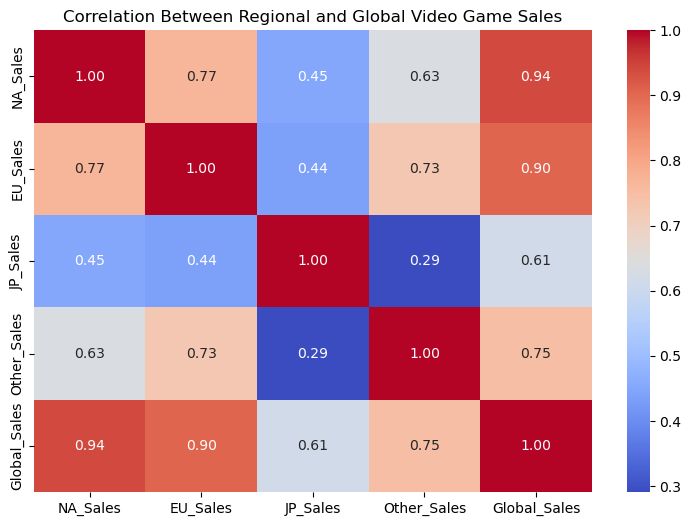

In [11]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    sales_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Regional and Global Video Game Sales")
plt.show()

### Interpretation

The correlation analysis shows that North American sales have the strongest relationship with global sales (**r = 0.94**), followed closely by European sales (**r = 0.90**). This suggests that games performing strongly in North America and Europe tend to have higher overall global sales.

Japanese sales have a weaker relationship with global sales (**r = 0.61**) compared with North America and Europe, suggesting that the Japanese market may exhibit different consumer preferences and purchasing patterns.

North American and European sales are also strongly correlated (**r = 0.77**), indicating similarities in sales performance across these two markets. In contrast, Japanese sales show weaker relationships with the other regional markets, particularly Other Sales (**r = 0.29**), which provides additional evidence of regional differences in video game demand.

These relationships are useful for understanding global market behavior. However, regional sales variables should not be used to predict `Global_Sales` because global sales are derived from regional sales totals, which would introduce data leakage into a predictive model.

## 5. Global Sales Outlier Analysis

Video game sales can vary substantially between titles, with a relatively small number of blockbuster games achieving exceptionally high sales. This section examines the distribution of global sales and identifies potential outliers that may influence statistical analysis and predictive modeling.


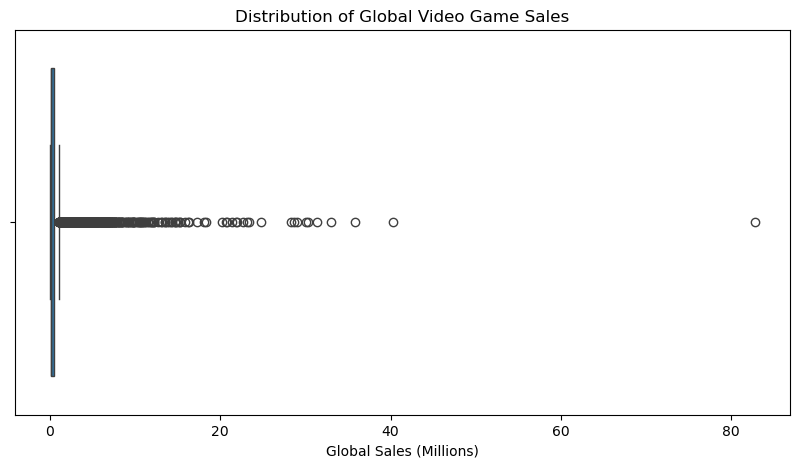

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Global_Sales"])

plt.title("Distribution of Global Video Game Sales")
plt.xlabel("Global Sales (Millions)")
plt.show()

In [13]:
Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.06
Q3: 0.48
IQR: 0.42
Lower Bound: -0.5700000000000001
Upper Bound: 1.1099999999999999


In [14]:
outliers = df[
    (df["Global_Sales"] < lower_bound) |
    (df["Global_Sales"] > upper_bound)
]

outliers.shape[0]

1826

### Outlier Analysis Interpretation

Using the IQR method, the first quartile (Q1) of Global Sales is 0.06 million units and the third quartile (Q3) is 0.48 million units, resulting in an IQR of 0.42 million units. The calculated upper outlier boundary is approximately 1.11 million units.

A total of 1,826 games exceed this threshold and are therefore classified as potential outliers by the IQR rule. However, these observations should not automatically be considered errors. The video game industry naturally contains blockbuster titles that sell substantially more units than typical games.

Removing these observations could eliminate meaningful information about highly successful games and distort the business analysis. Therefore, the outliers will be retained while their influence on future statistical analysis and predictive modeling will be considered.

In [16]:
outliers.sort_values("Global_Sales", ascending=False)[
    ["Name", "Platform", "Year", "Genre", "Global_Sales"]
].head(10)

,Name,Platform,Year,Genre,Global_Sales
0,Wii Sports,Wii,2006,Sports,82.74
1,Super Mario Bros.,NES,1985,Platform,40.24
2,Mario Kart Wii,Wii,2008,Racing,35.82
3,Wii Sports Resort,Wii,2009,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,31.37
5,Tetris,GB,1989,Puzzle,30.26
6,New Super Mario Bros.,DS,2006,Platform,30.01
7,Wii Play,Wii,2006,Misc,29.02
8,New Super Mario Bros. Wii,Wii,2009,Platform,28.62
9,Duck Hunt,NES,1984,Shooter,28.31


## 6. Log Transformation of Global Sales

The outlier analysis indicates that the extreme sales values represent legitimate blockbuster titles rather than data errors. Therefore, these observations will be retained. However, the strong right-skewness of `Global_Sales` may affect future statistical analysis and predictive modeling.

A logarithmic transformation is explored as an alternative way to reduce the influence of extreme values while preserving all observations.

In [17]:
df["Log_Global_Sales"] = np.log1p(df["Global_Sales"])

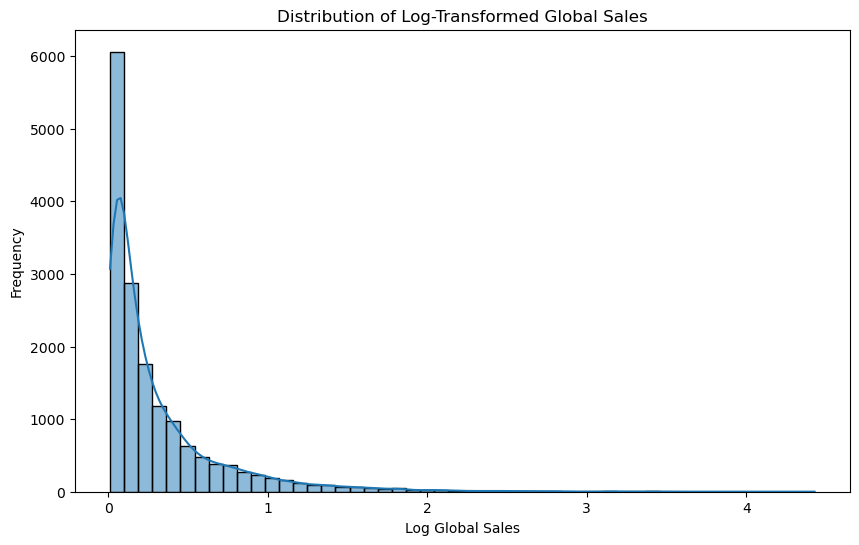

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Log_Global_Sales"], bins=50, kde=True)

plt.title("Distribution of Log-Transformed Global Sales")
plt.xlabel("Log Global Sales")
plt.ylabel("Frequency")

plt.show()

### Log Transformation Interpretation

The log transformation substantially reduces the influence of extreme global sales values while retaining all observations in the dataset. Although the transformed distribution remains right-skewed, the extreme upper tail is compressed considerably compared with the original sales distribution.

This suggests that a log-transformed version of `Global_Sales` may be useful during predictive modeling, particularly for models that are sensitive to highly skewed target variables. The transformation allows blockbuster titles to remain in the dataset while reducing their disproportionate influence on the model.

## 7. Genre and Sales Performance

Genre is a potential categorical predictor of video game sales. Rather than examining only total sales by genre, this section evaluates the typical sales performance of individual games within each genre.

Because global sales are highly right-skewed and influenced by blockbuster titles, median sales are used to provide a more robust comparison of typical game performance across genres.

In [20]:
genre_median = (
    df.groupby("Genre")["Global_Sales"]
      .median()
      .sort_values(ascending=False)
)

genre_median

Genre
Platform        0.280
Shooter         0.230
Sports          0.220
Fighting        0.210
Action          0.190
Racing          0.190
Role-Playing    0.190
Misc            0.160
Simulation      0.160
Puzzle          0.105
Strategy        0.090
Adventure       0.060
Name: Global_Sales, dtype: float64

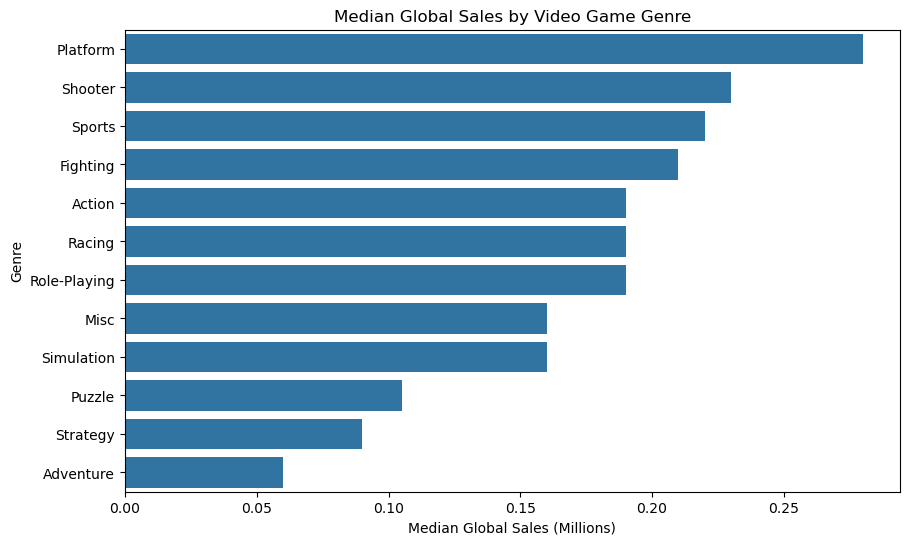

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_median.values,
    y=genre_median.index
)

plt.title("Median Global Sales by Video Game Genre")
plt.xlabel("Median Global Sales (Millions)")
plt.ylabel("Genre")

plt.show()

### Genre Analysis Interpretation

Median global sales vary noticeably across video game genres, suggesting that genre may provide useful information for predicting game-level sales performance.

Platform games have the highest median global sales at approximately 0.28 million units per title, followed by Shooter and Sports games at approximately 0.23 million and 0.22 million units, respectively. In contrast, Adventure games have the lowest median sales at approximately 0.06 million units.

The difference between the highest- and lowest-performing genres indicates that the typical sales performance of a game is associated with its genre. Therefore, `Genre` should be retained as a candidate categorical feature for future predictive modeling.

However, genre alone is unlikely to explain sales performance completely because substantial variation may still exist among individual games within the same genre.

## 8. Platform and Sales Performance

Platform is another potential categorical predictor of global video game sales. However, platforms with very few game releases may produce unstable or misleading median sales estimates.

To improve the reliability of the comparison, both the number of games and median global sales for each platform are examined before evaluating platform-level sales performance.

In [22]:
platform_stats = (
    df.groupby("Platform")["Global_Sales"]
      .agg(["count", "median"])
      .sort_values("median", ascending=False)
)

platform_stats

,count,median
Platform,,
NES,98,1.375
GB,97,1.180
2600,116,0.475
SNES,239,0.320
X360,1234,0.290
PS3,1304,0.290
N64,316,0.270
PS,1189,0.260
XOne,213,0.240


In [23]:
platform_stats_filtered = platform_stats[
    platform_stats["count"] >= 50
]

platform_stats_filtered

,count,median
Platform,,
NES,98,1.375
GB,97,1.180
2600,116,0.475
SNES,239,0.320
X360,1234,0.290
PS3,1304,0.290
N64,316,0.270
PS,1189,0.260
XOne,213,0.240


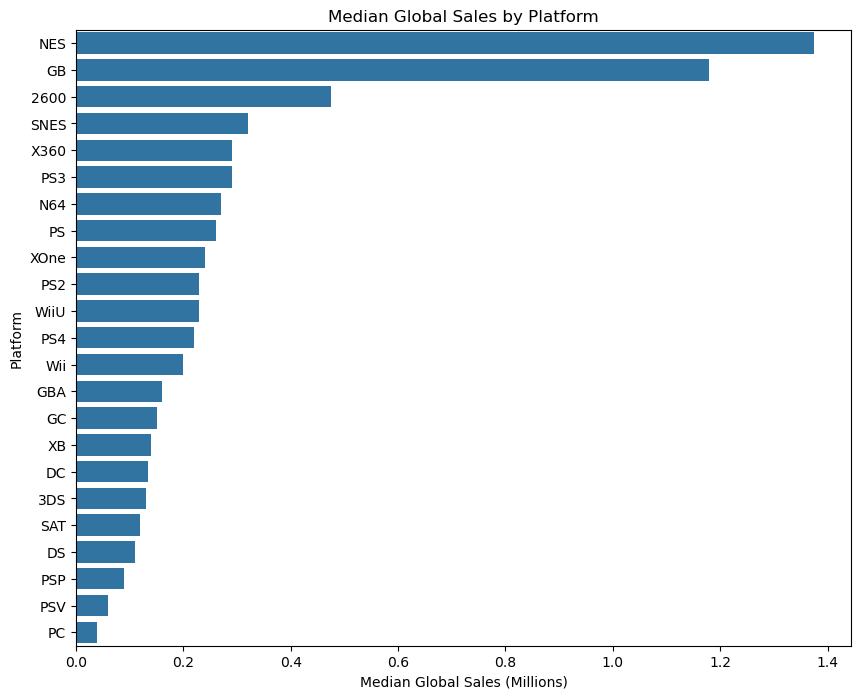

In [24]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=platform_stats_filtered["median"],
    y=platform_stats_filtered.index
)

plt.title("Median Global Sales by Platform")
plt.xlabel("Median Global Sales (Millions)")
plt.ylabel("Platform")

plt.show()

### Platform Analysis Interpretation

Median global sales vary substantially across established gaming platforms. After restricting the analysis to platforms with at least 50 game releases, NES and GB show the highest median global sales, while platforms such as PC and PSV show considerably lower median sales per title.

The large differences in median sales across platforms suggest that `Platform` contains meaningful information about game-level sales performance and should be retained as a candidate feature for predictive modeling.

However, these differences should not be interpreted as evidence that one platform inherently causes higher sales. Platform performance may also reflect differences in release era, market size, game availability, consumer behavior, and other factors. These relationships should therefore be evaluated alongside additional features during modeling.

## 9. Release Year and Sales Performance

Release year may provide useful information about video game sales because the size, structure, and competitive environment of the gaming industry have changed substantially over time.

Median global sales by release year are examined to determine whether the typical sales performance of individual games varies across different periods. This analysis may also help explain some of the differences observed between gaming platforms from different generations.

In [25]:
year_median = (
    df.groupby("Year")["Global_Sales"]
      .median()
      .sort_index()
)

year_median

Year
1980    0.770
1981    0.465
1982    0.540
1983    0.770
1984    1.485
1985    1.015
1986    1.360
1987    0.885
1988    1.510
1989    1.610
1990    1.520
1991    0.380
1992    0.780
1993    0.355
1994    0.270
1995    0.140
1996    0.220
1997    0.280
1998    0.260
1999    0.305
2000    0.250
2001    0.250
2002    0.170
2003    0.200
2004    0.210
2005    0.170
2006    0.110
2007    0.150
2008    0.170
2009    0.160
2010    0.150
2011    0.140
2012    0.170
2013    0.190
2014    0.165
2015    0.090
2016    0.050
2017    0.010
2020    0.290
Name: Global_Sales, dtype: float64

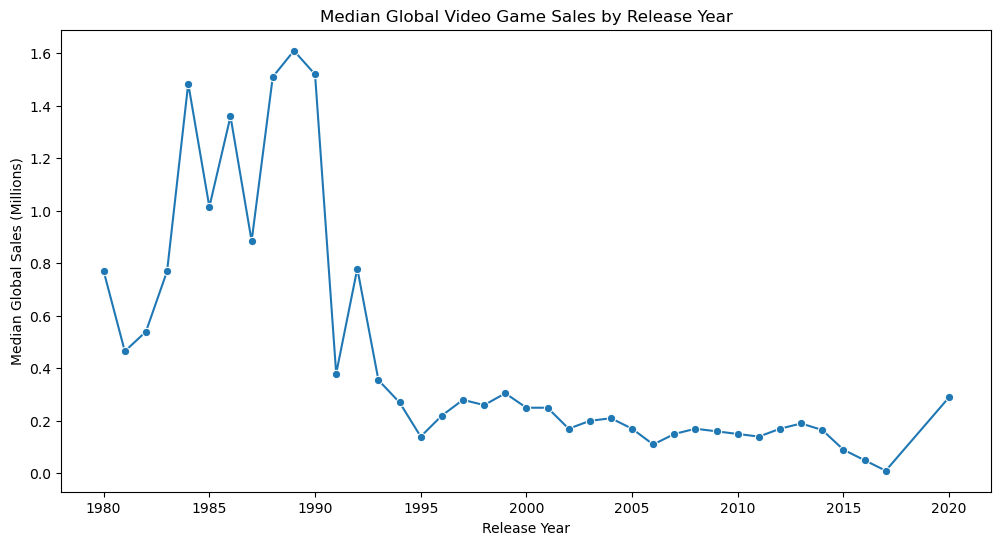

In [26]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=year_median.index,
    y=year_median.values,
    marker="o"
)

plt.title("Median Global Video Game Sales by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Median Global Sales (Millions)")

plt.show()

In [27]:
year_stats = (
    df.groupby("Year")["Global_Sales"]
      .agg(["count", "median"])
)

year_stats

,count,median
Year,,
1980,9,0.770
1981,46,0.465
1982,36,0.540
1983,17,0.770
1984,14,1.485
1985,14,1.015
1986,21,1.360
1987,16,0.885
1988,15,1.510


### Release Year Interpretation

Earlier release years generally show higher median global sales per game. However, these years also contain substantially fewer game releases, meaning their median values are based on smaller sample sizes and may be less stable.

As the video game industry expanded, the number of titles released increased considerably while median sales per game generally declined. This suggests that the apparent advantage of earlier release years may partly reflect differences in market size, competition, and the number of available titles rather than release year alone.

Therefore, `Year` may contain useful predictive information, but its relationship with global sales should be interpreted cautiously and considered alongside other features such as platform and genre.

## 10. Publisher and Sales Performance

Publisher may influence video game sales because established publishers can differ in brand recognition, marketing resources, distribution networks, and game portfolios.

However, publisher is a high-cardinality categorical feature, meaning the dataset contains many different publisher categories. Publishers with only a small number of games may produce unreliable sales estimates. Therefore, publisher frequency is examined before evaluating median sales performance.

In [28]:
df["Publisher"].nunique()

576

In [29]:
publisher_counts = df["Publisher"].value_counts()

publisher_counts.describe()

count     576.000000
mean       28.282986
std       115.417374
min         1.000000
25%         1.000000
50%         3.000000
75%        10.000000
max      1339.000000
Name: count, dtype: float64

In [30]:
publisher_counts.head(10)

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
THQ                              712
Nintendo                         696
Sony Computer Entertainment      682
Sega                             632
Take-Two Interactive             412
Name: count, dtype: int64

In [31]:
print("Publishers with fewer than 10 games:",
      (publisher_counts < 10).sum())

print("Publishers with fewer than 5 games:",
      (publisher_counts < 5).sum())

print("Publishers with only 1 game:",
      (publisher_counts == 1).sum())

Publishers with fewer than 10 games: 424
Publishers with fewer than 5 games: 343
Publishers with only 1 game: 192


### Publisher Frequency Interpretation

The dataset contains 576 unique publishers, indicating that `Publisher` is a high-cardinality categorical feature. Publisher representation is also highly uneven.

Of the 576 publishers, 424 have fewer than 10 games, 343 have fewer than 5 games, and 192 publishers appear only once in the dataset. This means that a large proportion of publisher categories contain relatively little information.

Directly one-hot encoding all publishers could create hundreds of sparse features, increasing model complexity. Therefore, publisher categories should be handled carefully during feature engineering. One potential strategy is to retain publishers with sufficient representation while grouping rare publishers into an `Other` category.

## 11. Established Publisher Sales Performance

Although `Publisher` is a high-cardinality feature with many sparsely represented categories, publisher identity may still contain useful information about sales performance.

To evaluate this relationship more reliably, publishers with at least 50 game releases are examined. Median global sales are used to reduce the influence of blockbuster titles and compare the typical sales performance of established publishers.

In [32]:
publisher_stats = (
    df.groupby("Publisher")["Global_Sales"]
      .agg(["count", "median"])
      .sort_values("median", ascending=False)
)

publisher_stats_filtered = publisher_stats[
    publisher_stats["count"] >= 50
]

publisher_stats_filtered.head(15)

,count,median
Publisher,,
Nintendo,696,0.920
SquareSoft,52,0.690
LucasArts,89,0.520
Bethesda Softworks,69,0.510
Electronic Arts,1339,0.470
Warner Bros. Interactive Entertainment,217,0.390
Microsoft Game Studios,189,0.360
Disney Interactive Studios,214,0.355
Sony Computer Entertainment,682,0.340


### Publisher Sales Interpretation

Among publishers with at least 50 game releases, median global sales vary substantially. Nintendo has the highest median global sales at approximately 0.92 million units per game, followed by SquareSoft at 0.69 million and LucasArts at 0.52 million.

The differences in median sales across established publishers suggest that `Publisher` contains potentially useful information about game-level sales performance and should be retained as a candidate feature for predictive modeling.

However, `Publisher` also contains 576 unique categories, many of which are sparsely represented. Therefore, the feature should not be directly one-hot encoded in its current form. Rare-category handling will be considered during the feature engineering stage to reduce dimensionality and improve model generalization.

## 12. Genre–Platform Interaction Analysis

Genre and platform have individually shown meaningful differences in median global sales. However, the effect of genre may also vary across gaming platforms.

This section examines Genre–Platform combinations to determine whether certain combinations are associated with stronger typical sales performance. To reduce instability from small sample sizes, only combinations containing at least 50 games are included in the comparison.

In [33]:
genre_platform_stats = (
    df.groupby(["Genre", "Platform"])["Global_Sales"]
      .agg(["count", "median"])
      .reset_index()
)

In [34]:
genre_platform_filtered = (
    genre_platform_stats[
        genre_platform_stats["count"] >= 50
    ]
    .sort_values("median", ascending=False)
)

genre_platform_filtered.head(15)

,Genre,Platform,count,median
210,Shooter,PS3,155,0.570
63,Fighting,PS3,76,0.485
182,Role-Playing,PS,97,0.450
219,Shooter,X360,197,0.410
111,Platform,PS2,101,0.400
0,Action,2600,55,0.380
12,Action,PS2,345,0.360
71,Fighting,X360,65,0.360
194,Role-Playing,X360,75,0.330
119,Platform,Wii,57,0.330


### Genre–Platform Interaction Interpretation

The Genre–Platform analysis reveals substantial differences in median global sales across specific combinations. Among combinations with at least 50 games, Shooter games on PS3 have the highest median global sales at approximately 0.57 million units, followed by Fighting games on PS3 at 0.485 million and Role-Playing games on PS at 0.45 million.

The results also show that the same genre can perform differently across platforms. For example, Shooter games have median global sales of approximately 0.57 million on PS3 compared with 0.41 million on X360.

These differences suggest that Genre and Platform may have an interaction effect, meaning that the relationship between genre and sales may depend partly on the platform on which the game is released. A Genre–Platform interaction feature may therefore be worth evaluating during feature engineering and predictive modeling.

## 13. Feature Analysis Summary

The advanced exploratory analysis identified several important relationships and modeling considerations that will guide the feature engineering and predictive modeling stages.

### Candidate Predictive Features

- **Genre:** Median global sales vary across genres, suggesting that genre contains useful information about typical game-level sales performance.

- **Platform:** Substantial differences in median sales were observed across established platforms, supporting Platform as a candidate predictor.

- **Year:** Sales performance varies over time, although early years contain relatively small sample sizes. Year may provide useful information about changes in the video game market but should be interpreted alongside other variables.

- **Publisher:** Established publishers show meaningful differences in median global sales. However, Publisher contains 576 unique categories and many sparsely represented publishers, requiring rare-category handling during feature engineering.

- **Genre–Platform Interaction:** Certain Genre–Platform combinations show substantially different median sales, suggesting that an interaction feature may provide additional predictive information.

### Target Variable Considerations

`Global_Sales` is highly right-skewed and contains legitimate blockbuster titles that appear as statistical outliers. These observations will be retained because they represent meaningful commercial outcomes rather than obvious data errors.

A log-transformed version of Global Sales reduced the influence of extreme values and will be considered as an alternative target during predictive modeling.

### Variables Excluded as Predictors

Regional sales variables (`NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`) are strongly related to `Global_Sales`. However, because Global Sales is derived from these regional sales values, using them as predictors would introduce data leakage. They will therefore be excluded from models predicting Global Sales.

### Feature Engineering Considerations

The next stage of the project will evaluate:

1. Encoding of categorical variables such as Genre and Platform.
2. Rare-category handling for Publisher.
3. A potential Genre–Platform interaction feature.
4. Appropriate treatment of Year.
5. Original versus log-transformed Global Sales as the modeling target.
6. Prevention of data leakage by fitting preprocessing decisions using training data only.

## Next Step: Feature Engineering

The findings from this notebook provide the foundation for feature engineering. The next stage will transform the selected variables into model-ready features while ensuring that preprocessing decisions are learned from the training data and applied consistently to unseen data.